# Datos reales — engranajes XYZ etiquetados

Carga de datos de medición reales: nube de puntos XYZ en formato `.raw` y máscara de segmentación de defecto en formato YOLO (`.txt`).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import cv2
import os
import sys

# Añadir el directorio raíz del proyecto al path para importar camera.raw
sys.path.insert(0, os.path.abspath(".."))
import camera.raw as raw

## 1. Cargar datos XYZ

El archivo `.raw` tiene header `IMG_INFO` + nr/nc (int32 LE) + tag `F34B` (3 canales float32 → X, Y, Z).

In [2]:
SAMPLE = "151225_160136_P44512_S2_7761"
BASE = f"../gears_defectos_xyz_etiquetados/{SAMPLE}/debug/entities"

xyz_path  = f"{BASE}/save_xyz/{SAMPLE}_save_xyz.raw"
mask_path = f"{BASE}/rgb_seg/{SAMPLE}_rgb_seg.txt"

# Leer XYZ: shape (H, W, 3) → canales [X, Y, Z]
xyz = raw.read_img_raw(xyz_path)
H, W = xyz.shape[:2]
X, Y, Z = xyz[:, :, 0], xyz[:, :, 1], xyz[:, :, 2]

print(f"Shape XYZ : {xyz.shape}")
print(f"X range   : [{X.min():.3f}, {X.max():.3f}] mm")
print(f"Y range   : [{Y.min():.3f}, {Y.max():.3f}] mm")
print(f"Z range   : [{Z.min():.3f}, {Z.max():.3f}] mm")

Shape XYZ : (790, 1129, 3)
X range   : [-59.985, 88.030] mm
Y range   : [-48.351, 48.657] mm
Z range   : [0.000, 21.330] mm


## 2. Cargar máscara de segmentación

Formato YOLO segmentación: una línea por objeto → `clase x1 y1 x2 y2 ... xN yN` con coordenadas normalizadas a [0,1].

In [3]:
def load_yolo_seg_mask(txt_path, img_h, img_w):
    """
    Lee una máscara YOLO segmentation (polígono normalizado) y devuelve:
      - polygons : lista de arrays (N,2) en píxeles [col, row]
      - mask     : imagen binaria (img_h, img_w) uint8
    """
    polygons = []
    mask = np.zeros((img_h, img_w), dtype=np.uint8)
    with open(txt_path, "r") as f:
        for line in f:
            vals = line.strip().split()
            if len(vals) < 5:
                continue
            # primer valor = clase, el resto son pares x,y normalizados
            coords = np.array(vals[1:], dtype=float).reshape(-1, 2)
            pts_px = (coords * np.array([img_w, img_h])).astype(np.int32)
            polygons.append(pts_px)
            cv2.fillPoly(mask, [pts_px], 1)
    return polygons, mask


polygons, defect_mask = load_yolo_seg_mask(mask_path, H, W)

print(f"Número de polígonos : {len(polygons)}")
for i, p in enumerate(polygons):
    print(f"  Polígono {i}: {len(p)} vértices")
print(f"Píxeles en máscara  : {defect_mask.sum()}")

Número de polígonos : 1
  Polígono 0: 93 vértices
Píxeles en máscara  : 5489


## 3. Visualización

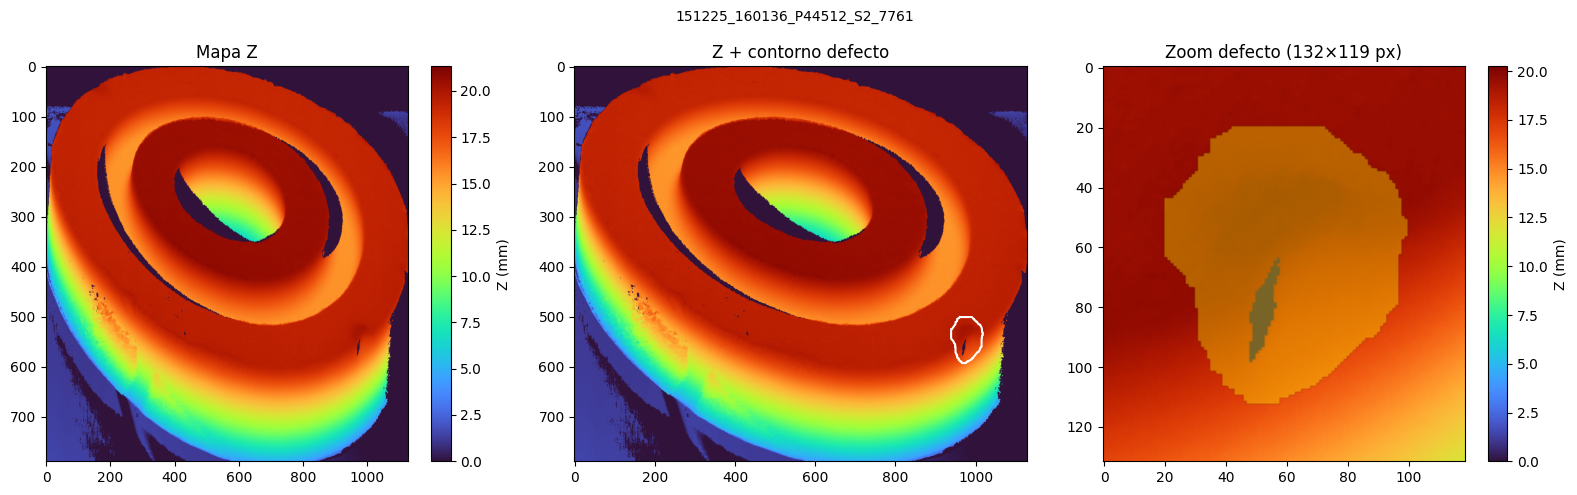

In [4]:
plt.close("all")
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# — Mapa Z completo
im0 = axes[0].imshow(Z, cmap="turbo", aspect="auto")
fig.colorbar(im0, ax=axes[0], label="Z (mm)")
axes[0].set_title("Mapa Z")

# — Mapa Z con contorno de la máscara superpuesto
axes[1].imshow(Z, cmap="turbo", aspect="auto")
for pts in polygons:
    closed = np.vstack([pts, pts[0]])
    axes[1].plot(closed[:, 0], closed[:, 1], "w-", linewidth=1.5)
axes[1].set_title("Z + contorno defecto")

# — Zoom en la región del defecto (bounding box del polígono)
if polygons:
    all_pts = np.vstack(polygons)
    r0, r1 = all_pts[:, 1].min(), all_pts[:, 1].max()
    c0, c1 = all_pts[:, 0].min(), all_pts[:, 0].max()
    pad = 20
    r0, r1 = max(0, r0 - pad), min(H, r1 + pad)
    c0, c1 = max(0, c0 - pad), min(W, c1 + pad)
    Z_crop = Z[r0:r1, c0:c1]
    mask_crop = defect_mask[r0:r1, c0:c1]
    im2 = axes[2].imshow(Z_crop, cmap="turbo", aspect="auto")
    fig.colorbar(im2, ax=axes[2], label="Z (mm)")
    # overlay semitransparente de la máscara
    overlay = np.zeros((*Z_crop.shape, 4), dtype=float)
    overlay[mask_crop == 1] = [1, 1, 0, 0.35]   # amarillo semitransparente
    axes[2].imshow(overlay, aspect="auto")
    axes[2].set_title(f"Zoom defecto ({r1-r0}×{c1-c0} px)")

plt.suptitle(SAMPLE, fontsize=10)
plt.tight_layout()
plt.show()

## 4. Normalización polinomial local

La pieza es un eje de forja (geometría cilíndrica compleja, sin modelo analítico previo).  
Estrategia: ajustar un **polinomio 2D de grado `POLY_DEG`** a los píxeles de una **corona alrededor del defecto** (excluyendo los píxeles del defecto mismo). Eso da la superficie nominal `Z_nom`. Entonces:

$$Z_{\text{diff}} = Z - Z_{\text{nom}}$$

La corona se construye dilatando la máscara `RING_PX` píxeles y restando la máscara original.

In [5]:
from scipy.cluster.vq import kmeans2

# ── Parámetros ──────────────────────────────────────────────────────────────
RING_LOCAL_MM = 8.0   # anchura del anillo de muestras alrededor del defecto (mm)
POLY_DEG      = 2     # grado del polinomio: 1=plano, 2=cuádrica, 3=cúbico
K_FACETS      = 3     # número de facetas geométricas a detectar automáticamente
SG_WIN_PX     = 31    # ventana SG 2D en píxeles (impar) para estimar gradiente
# ────────────────────────────────────────────────────────────────────────────

# Píxeles válidos (Z=0 → sin medición)
valid_mask = np.isfinite(Z) & (Z != 0)

# Resolución aproximada (mm/px) — rango físico / dimensión imagen en región válida
# Usada solo para convertir RING_LOCAL_MM a píxeles
x_valid = X[valid_mask];  y_valid = Y[valid_mask]
dx = (x_valid.max() - x_valid.min()) / W
dy = (y_valid.max() - y_valid.min()) / H
pix_mm = (dx + dy) / 2        # resolución media isotrópica
ring_local_px = int(round(RING_LOCAL_MM / pix_mm)) | 1
print(f"Resolución media: {pix_mm:.4f} mm/px  →  anillo {RING_LOCAL_MM} mm = {ring_local_px} px")

# ── SG 2D (paraboloide): devuelve tensor (H,W,6) con coefs [a,b,c,d,e,f0] ──
def sg2d_jacobian_projection_cv2(Z, window_size=11):
    assert window_size % 2 == 1
    hw = window_size // 2
    y_idx, x_idx = np.mgrid[-hw:hw+1, -hw:hw+1]
    regressors = np.stack([
        x_idx**2, y_idx**2, x_idx * y_idx,
        x_idx, y_idx, np.ones_like(x_idx)
    ], axis=-1)
    A_mat = regressors.reshape(-1, 6)
    pseudo = np.linalg.inv(A_mat.T @ A_mat) @ A_mat.T
    kernels = pseudo.reshape(6, window_size, window_size)
    return np.stack(
        [cv2.filter2D(Z.astype(np.float64), -1, k,
                      borderType=cv2.BORDER_REFLECT) for k in kernels],
        axis=-1
    )

# ── Gradiente SG 2D en espacio píxel (solo necesitamos DIRECCIÓN) ────────────
print(f"Ventana SG 2D: {SG_WIN_PX} px")
Z_filled  = np.where(valid_mask, Z, 0.0)
coeffs_px = sg2d_jacobian_projection_cv2(Z_filled, SG_WIN_PX)
# coef [3] = dZ/d(col),  coef [4] = dZ/d(row)  — en espacio píxel
gx_px = coeffs_px[..., 3]
gy_px = coeffs_px[..., 4]

# ── Anillo de muestras ───────────────────────────────────────────────────────
kernel_rl     = cv2.getStructuringElement(
    cv2.MORPH_ELLIPSE, (ring_local_px, ring_local_px))
mask_outer_rl = cv2.dilate(defect_mask, kernel_rl).astype(bool)
mask_ring_rl  = mask_outer_rl & ~defect_mask.astype(bool) & valid_mask
print(f"Anillo: {RING_LOCAL_MM} mm → {ring_local_px} px  |  puntos={mask_ring_rl.sum()}")

# ── Función de diseño polinomial ─────────────────────────────────────────────
def poly2d_design(x, y, deg=2):
    terms = [np.ones_like(x)]
    for d in range(1, deg + 1):
        for k in range(d + 1):
            terms.append(x ** (d - k) * y ** k)
    return np.column_stack(terms)

# ── Clustering del anillo por dirección del gradiente SG (píxel) ─────────────
r_idx, c_idx = np.where(mask_ring_rl)
xp   = X[r_idx, c_idx].astype(float)    # coordenadas físicas para el polinomio
yp   = Y[r_idx, c_idx].astype(float)
zp   = Z[r_idx, c_idx].astype(float)
gxp  = gx_px[r_idx, c_idx]              # gradiente en px para clustering
gyp  = gy_px[r_idx, c_idx]

theta = np.arctan2(gyp, gxp)
feat  = np.column_stack([np.cos(theta), np.sin(theta)])
_, labels = kmeans2(feat, K_FACETS, seed=42, minit='points')

print(f"\nK={K_FACETS} facetas geométricas:")
coeffs_list = []
for k in range(K_FACETS):
    sel = labels == k
    A = poly2d_design(xp[sel], yp[sel], POLY_DEG)
    coef, _, _, _ = np.linalg.lstsq(A, zp[sel], rcond=None)
    rms = float(np.sqrt(np.mean((A @ coef - zp[sel])**2)))
    g_mean = np.degrees(np.arctan2(gyp[sel].mean(), gxp[sel].mean()))
    print(f"  Faceta {k}: {sel.sum():5d} px  |  RMS={rms*1e3:.1f} µm  |  ∇ medio={g_mean:.1f}°")
    coeffs_list.append(coef)

# ── Evaluar Z_nom como blend IDW por centroide de faceta ─────────────────────
r0_bb = max(0, r_idx.min() - ring_local_px)
r1_bb = min(H, r_idx.max() + ring_local_px + 1)
c0_bb = max(0, c_idx.min() - ring_local_px)
c1_bb = min(W, c_idx.max() + ring_local_px + 1)

X_ev = X[r0_bb:r1_bb, c0_bb:c1_bb].astype(float)
Y_ev = Y[r0_bb:r1_bb, c0_bb:c1_bb].astype(float)
hr, wc = X_ev.shape

A_full   = poly2d_design(X_ev.ravel(), Y_ev.ravel(), POLY_DEG)
Z_noms_k = np.stack([(A_full @ coef).reshape(hr, wc) for coef in coeffs_list], axis=0)

centroids = np.array([[xp[labels==k].mean(), yp[labels==k].mean()] for k in range(K_FACETS)])
dists2    = np.stack([((X_ev - cx)**2 + (Y_ev - cy)**2) for cx, cy in centroids], axis=0) + 1e-6
weights   = 1.0 / dists2
weights  /= weights.sum(axis=0, keepdims=True)

Z_nom_ev = (weights * Z_noms_k).sum(axis=0)

Z_nom  = Z.copy()
Z_nom[r0_bb:r1_bb, c0_bb:c1_bb] = Z_nom_ev
Z_diff = np.where(valid_mask, Z - Z_nom, np.nan)

z_def = Z_diff[defect_mask.astype(bool)]
print(f"\nZ_diff en máscara defecto:  min={np.nanmin(z_def):.4f}  max={np.nanmax(z_def):.4f}  std={np.nanstd(z_def):.4f} mm")

Resolución media: 0.1269 mm/px  →  anillo 8.0 mm = 63 px
Ventana SG 2D: 31 px
Anillo: 8.0 mm → 63 px  |  puntos=11655

K=3 facetas geométricas:
  Faceta 0:  1096 px  |  RMS=39.5 µm  |  ∇ medio=25.0°
  Faceta 1:  3940 px  |  RMS=38.8 µm  |  ∇ medio=73.8°
  Faceta 2:  6619 px  |  RMS=1345.1 µm  |  ∇ medio=-119.7°

Z_diff en máscara defecto:  min=-2.1399  max=3.8858  std=1.3612 mm


/tmp/ipykernel_20489/411620386.py:41: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_f = plt.cm.get_cmap("Set1", K_FACETS)


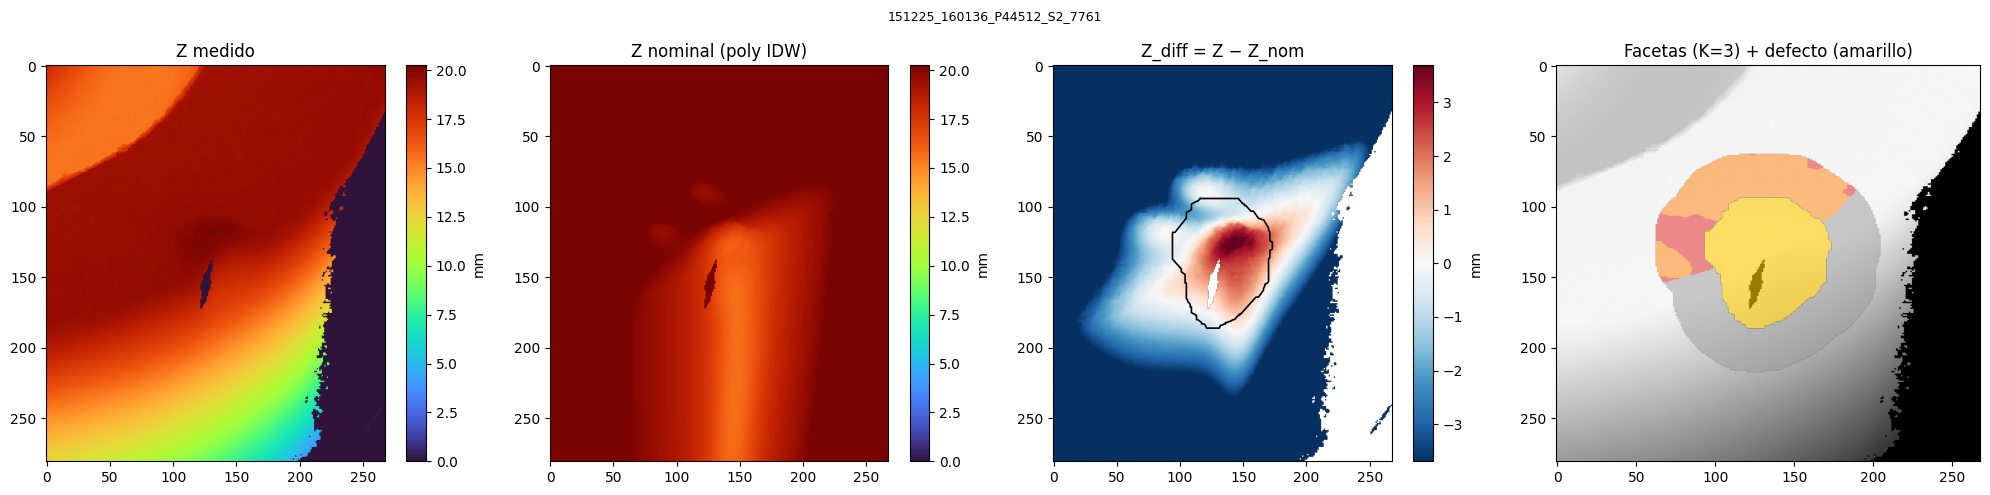

In [6]:
# — Bounding box para los plots (reutiliza r0_bb calculado en la celda anterior)
def crop(arr):
    return arr[r0_bb:r1_bb, c0_bb:c1_bb]

Z_cr      = crop(Z)
Z_nom_cr  = crop(Z_nom)
Z_diff_cr = crop(Z_diff)
ring_cr   = crop(mask_ring_rl)
mask_cr   = crop(defect_mask.astype(bool))

# Mapa de facetas en el crop (para visualización)
labels_img = np.full((H, W), -1, dtype=np.int16)
labels_img[r_idx, c_idx] = labels
labels_cr  = crop(labels_img)

# — Límites colorbar Z_diff simétrico
vmax_diff = np.nanpercentile(np.abs(Z_diff_cr[mask_cr]), 99)

plt.close("all")
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

# Z medido
im0 = axes[0].imshow(Z_cr, cmap="turbo", aspect="auto")
fig.colorbar(im0, ax=axes[0], label="mm"); axes[0].set_title("Z medido")

# Z nominal
im1 = axes[1].imshow(Z_nom_cr, cmap="turbo", aspect="auto",
                     vmin=np.nanmin(Z_cr), vmax=np.nanmax(Z_cr))
fig.colorbar(im1, ax=axes[1], label="mm"); axes[1].set_title("Z nominal (poly IDW)")

# Z_diff
im2 = axes[2].imshow(Z_diff_cr, cmap="RdBu_r", aspect="auto",
                     vmin=-vmax_diff, vmax=vmax_diff)
fig.colorbar(im2, ax=axes[2], label="mm"); axes[2].set_title("Z_diff = Z − Z_nom")
for pts in polygons:
    pts_local = pts - np.array([c0_bb, r0_bb])
    closed = np.vstack([pts_local, pts_local[0]])
    axes[2].plot(closed[:, 0], closed[:, 1], "k-", linewidth=1.2)

# Facetas + defecto
cmap_f = plt.cm.get_cmap("Set1", K_FACETS)
facet_vis = np.zeros((*Z_cr.shape, 4), dtype=float)
for k in range(K_FACETS):
    c = cmap_f(k)
    facet_vis[labels_cr == k] = [c[0], c[1], c[2], 0.5]
mask_vis = np.zeros((*Z_cr.shape, 4), dtype=float)
mask_vis[mask_cr] = [1.0, 0.8, 0.0, 0.6]

axes[3].imshow(Z_cr, cmap="gray", aspect="auto")
axes[3].imshow(facet_vis, aspect="auto")
axes[3].imshow(mask_vis, aspect="auto")
axes[3].set_title(f"Facetas (K={K_FACETS}) + defecto (amarillo)")

plt.suptitle(SAMPLE, fontsize=9)
plt.tight_layout()
plt.show()

## 5. Multi-Splat: funciones

In [7]:
import time as _time
from scipy.optimize import least_squares

def gauss2d_rotated(params, x, y):
    A_p, x0_p, y0_p, sx_p, sy_p, th_p = params
    c, s = np.cos(th_p), np.sin(th_p)
    u =  (x - x0_p) * c + (y - y0_p) * s
    v = -(x - x0_p) * s + (y - y0_p) * c
    return A_p * np.exp(-0.5 * (u**2 / sx_p**2 + v**2 / sy_p**2))

def gauss_mixture(params, x, y):
    K = len(params) // 6
    out = np.zeros(len(x))
    for k in range(K):
        out += gauss2d_rotated(params[6*k:6*k+6], x, y)
    return out

def gauss_mixture_and_jac(params, x, y):
    K = len(params) // 6
    N = len(x)
    out = np.zeros(N); J = np.zeros((N, 6*K))
    for k in range(K):
        A_p, x0_p, y0_p, sx_p, sy_p, th_p = params[6*k:6*k+6]
        c, s = np.cos(th_p), np.sin(th_p)
        dxv = x - x0_p; dyv = y - y0_p
        u =  dxv*c + dyv*s; v = -dxv*s + dyv*c
        eu2 = u**2/sx_p**2; ev2 = v**2/sy_p**2
        g = A_p * np.exp(-0.5*(eu2+ev2))
        out += g
        J[:, 6*k]   = g / A_p
        J[:, 6*k+1] = g * (u*c/sx_p**2 - v*s/sy_p**2)
        J[:, 6*k+2] = g * (u*s/sx_p**2 + v*c/sy_p**2)
        J[:, 6*k+3] = g * eu2 / sx_p
        J[:, 6*k+4] = g * ev2 / sy_p
        J[:, 6*k+5] = g * (u*v/sx_p**2 - u*v/sy_p**2)
    return out, J

def volume_mixture(params):
    K = len(params) // 6
    return sum(params[6*k] * 2*np.pi * params[6*k+3] * params[6*k+4] for k in range(K))

class _CachedFit:
    def __init__(self):
        self._p_last = None; self._r_last = None; self._j_last = None
    def update(self, p, x, y, z):
        p = np.asarray(p)
        if self._p_last is None or not np.array_equal(p, self._p_last):
            self._p_last = p.copy()
            fit_v, j_v = gauss_mixture_and_jac(p, x, y)
            self._r_last = fit_v - z; self._j_last = j_v
    def r(self): return self._r_last
    def j(self): return self._j_last

def _make_cached_fit(K_, x_, y_, z_):
    cf = _CachedFit()
    def fun(p): cf.update(p, x_, y_, z_); return cf.r()
    def jac(p): cf.update(p, x_, y_, z_); return cf.j()
    return fun, jac

print('Funciones Multi-Splat definidas.')

Funciones Multi-Splat definidas.


## 6. Multi-Splat: ajuste K=1..51

In [8]:
# ── Parámetros Multi-Splat ───────────────────────────────────────────────────
WIN_DEFECT_MM = 4.0
WIN_DEFECT_PX = int(round(WIN_DEFECT_MM / pix_mm)) | 1
K_MAX         = 15

# Extensión del defecto en pixel-mm (solo píxeles válidos)
rows_def, cols_def = np.where(defect_mask.astype(bool) & valid_mask)
X_MIN_PX = float(cols_def.min()) * pix_mm
X_MAX_PX = float(cols_def.max()) * pix_mm
Y_MIN_PX = float(rows_def.min()) * pix_mm
Y_MAX_PX = float(rows_def.max()) * pix_mm
SPAN_X_PX = X_MAX_PX - X_MIN_PX
SPAN_Y_PX = Y_MAX_PX - Y_MIN_PX
SIG_LONG  = SPAN_X_PX / 2.0
SIG_SHORT = SPAN_Y_PX / 2.0

print(f"Región: X=[{X_MIN_PX:.2f}, {X_MAX_PX:.2f}]  Y=[{Y_MIN_PX:.2f}, {Y_MAX_PX:.2f}] mm")
print(f"SPAN_X={SPAN_X_PX:.2f}  SPAN_Y={SPAN_Y_PX:.2f}  "
      f"SIG_LONG={SIG_LONG:.2f}  SIG_SHORT={SIG_SHORT:.2f}")

def run_multisplat(Z_diff_source, label):
    """Ajusta K=1..K_MAX gaussianas a la parte POSITIVA de Z_diff_source.
    Para el lado negativo, llama con -Z_diff."""
    mask_def_b = defect_mask.astype(bool) & valid_mask
    rows_m_, cols_m_ = np.where(mask_def_b)
    x_obs_ = cols_m_.astype(np.float64) * pix_mm
    y_obs_ = rows_m_.astype(np.float64) * pix_mm
    # Solo parte positiva
    z_obs_ = np.clip(Z_diff_source[rows_m_, cols_m_].astype(np.float64), 0.0, None)

    N_obs_ = len(z_obs_)
    N_SUB_ = min(2000, N_obs_)
    rng_   = np.random.default_rng(7)
    idx_   = rng_.choice(N_obs_, N_SUB_, replace=False)
    x_s = x_obs_[idx_]; y_s = y_obs_[idx_]; z_s = z_obs_[idx_]

    A_max_ = max(float(z_obs_.max()) * 3.0, 0.1)
    # Centros restringidos al interior del defecto; σ puede extenderse fuera
    blo = [0,       X_MIN_PX, Y_MIN_PX, 0.15, 0.15, -np.pi/2]
    bhi = [A_max_,  X_MAX_PX, Y_MAX_PX, SIG_LONG, SIG_SHORT,  np.pi/2]

    coeffs_d_px = sg2d_jacobian_projection_cv2(
        np.where(np.isfinite(Z_diff_source),
                 np.clip(Z_diff_source, 0.0, None), 0.0),
        WIN_DEFECT_PX)
    coeffs_d_ph = np.stack([
        coeffs_d_px[..., 0] / pix_mm**2,
        coeffs_d_px[..., 1] / pix_mm**2,
        coeffs_d_px[..., 2] / pix_mm**2,
        coeffs_d_px[..., 3] / pix_mm,
        coeffs_d_px[..., 4] / pix_mm,
        coeffs_d_px[..., 5]
    ], axis=-1)

    res_all = {}; p_cur = []
    print(f'\n── {label} ──')
    t0 = _time.perf_counter()

    for K in range(1, K_MAX + 1):
        prev_full = gauss_mixture(p_cur, x_obs_, y_obs_) if p_cur else np.zeros(N_obs_)
        res_prev  = np.clip(z_obs_ - prev_full, 0.0, None)
        res_img_  = np.zeros_like(Z_diff_source)
        res_img_[rows_m_, cols_m_] = res_prev
        f_ws = np.where(mask_def_b, res_img_, -np.inf)
        pr, pc = np.unravel_index(np.argmax(f_ws), f_ws.shape)
        mX_ws = float(pc) * pix_mm
        mY_ws = float(pr) * pix_mm

        a0_, b0_, c0_, d0_, e0_, f0_ = coeffs_d_ph[pr, pc, :]
        Hm = np.array([[2*a0_, c0_], [c0_, 2*b0_]])
        try:
            dlt_ = -np.linalg.solve(Hm, [d0_, e0_])
            mX_ws = float(np.clip(mX_ws + dlt_[0], blo[1]+1e-6, bhi[1]-1e-6))
            mY_ws = float(np.clip(mY_ws + dlt_[1], blo[2]+1e-6, bhi[2]-1e-6))
            A_ws_ = float(np.clip(f0_, blo[0]+1e-6, bhi[0]-1e-6))
            Sm = -A_ws_ * np.linalg.inv(Hm) if A_ws_ > 1e-6 else None
            if Sm is not None:
                ev__, evec__ = np.linalg.eigh(Sm)
                ord__ = np.argsort(ev__)[::-1]
                sx_ = float(np.clip(np.sqrt(abs(ev__[ord__[0]])), blo[3]+1e-6, bhi[3]-1e-6))
                sy_ = float(np.clip(np.sqrt(abs(ev__[ord__[1]])), blo[4]+1e-6, bhi[4]-1e-6))
                th_ = float(np.arctan2(evec__[1, ord__[0]], evec__[0, ord__[0]]))
            else:
                sx_, sy_, th_ = SIG_LONG * 0.3, SIG_SHORT * 0.4, 0.0
        except Exception:
            A_ws_ = float(np.clip(res_img_[pr, pc], blo[0]+1e-6, bhi[0]-1e-6))
            sx_, sy_, th_ = SIG_LONG * 0.3, SIG_SHORT * 0.4, 0.0

        p_new_ = [float(np.clip(A_ws_, blo[0]+1e-6, bhi[0]-1e-6)),
                  float(np.clip(mX_ws, blo[1]+1e-6, bhi[1]-1e-6)),
                  float(np.clip(mY_ws, blo[2]+1e-6, bhi[2]-1e-6)),
                  float(np.clip(sx_,   blo[3]+1e-6, bhi[3]-1e-6)),
                  float(np.clip(sy_,   blo[4]+1e-6, bhi[4]-1e-6)),
                  float(np.clip(th_,   blo[5]+1e-6, bhi[5]-1e-6))]
        p0_ = p_cur + p_new_
        fun_, jac_ = _make_cached_fit(K, x_s, y_s, z_s)
        rK = least_squares(fun_, p0_, jac=jac_,
                           bounds=(blo*K, bhi*K), method='trf',
                           xtol=1e-9, ftol=1e-9, gtol=1e-9, max_nfev=20_000)
        p_cur = list(rK.x)
        V_K_  = volume_mixture(p_cur)
        t_K_  = _time.perf_counter() - t0
        res_all[K] = dict(params=p_cur.copy(), V=V_K_, nfev=rK.nfev, t=t_K_)
        print(f'  K={K}: V={V_K_:.4f} mm³  nfev={rK.nfev}  t={t_K_*1000:.0f}ms')

    return res_all

Z_diff_clean = np.nan_to_num(Z_diff, nan=0.0)

# Ajuste lado positivo (protuberancias) y lado negativo (hundimientos)
print('=== LADO POSITIVO (protuberancias) ===')
results_pos = run_multisplat(Z_diff_clean,
    f'Polinomial local — lado positivo')

print('\n=== LADO NEGATIVO (hundimientos) ===')
results_neg = run_multisplat(-Z_diff_clean,
    f'Polinomial local — lado negativo')

Región: X=[119.20, 129.23]  Y=[63.60, 75.28] mm
SPAN_X=10.03  SPAN_Y=11.68  SIG_LONG=5.01  SIG_SHORT=5.84
=== LADO POSITIVO (protuberancias) ===

── Polinomial local — lado positivo ──
  K=1: V=137.6503 mm³  nfev=18  t=5ms
  K=2: V=141.6379 mm³  nfev=18  t=10ms
  K=3: V=235.3102 mm³  nfev=15  t=16ms
  K=4: V=199.8724 mm³  nfev=18  t=25ms
  K=5: V=157.3043 mm³  nfev=18  t=45ms
  K=6: V=167.9815 mm³  nfev=18  t=60ms
  K=7: V=155.9237 mm³  nfev=19  t=92ms
  K=8: V=168.1877 mm³  nfev=18  t=130ms
  K=9: V=189.1131 mm³  nfev=22  t=229ms
  K=10: V=143.9300 mm³  nfev=20  t=298ms
  K=11: V=160.6257 mm³  nfev=19  t=392ms
  K=12: V=133.8018 mm³  nfev=33  t=609ms
  K=13: V=134.3250 mm³  nfev=35  t=801ms
  K=14: V=132.6612 mm³  nfev=71  t=1410ms
  K=15: V=133.7548 mm³  nfev=53  t=1991ms

=== LADO NEGATIVO (hundimientos) ===

── Polinomial local — lado negativo ──
  K=1: V=27.4108 mm³  nfev=78  t=19ms
  K=2: V=27.0740 mm³  nfev=19  t=26ms
  K=3: V=25.2643 mm³  nfev=19  t=39ms
  K=4: V=26.6356 mm³  n

## 7. Resultados Multi-Splat

In [12]:
def bic_for(results_dict, sign=1):
    """sign=+1 para positivo, -1 para negativo (usamos -Z_diff para neg)."""
    mask_def_b = defect_mask.astype(bool) & valid_mask
    rows_m, cols_m = np.where(mask_def_b)
    xo = cols_m.astype(np.float64) * pix_mm
    yo = rows_m.astype(np.float64) * pix_mm
    zo = np.clip(sign * np.nan_to_num(Z_diff, nan=0.0)[rows_m, cols_m], 0.0, None)
    K_vals_ = sorted(results_dict.keys())
    bics = []
    for k in K_vals_:
        fit = gauss_mixture(results_dict[k]['params'], xo, yo)
        rss = np.sum((zo - fit)**2)
        bics.append(rss + 6*k * np.var(zo))
    K_best_ = K_vals_[int(np.argmin(bics))]
    return bics, K_best_

K_vals = sorted(results_pos.keys())

bic_pos, K_best_pos = bic_for(results_pos, sign=+1)
bic_neg, K_best_neg = bic_for(results_neg, sign=-1)

V_pos = results_pos[K_best_pos]['V']
V_neg = results_neg[K_best_neg]['V']

print(f'POSITIVO: K_best={K_best_pos}  V_pos = +{V_pos:.4f} mm³  (material sobrante)')
print(f'NEGATIVO: K_best={K_best_neg}  V_neg = -{V_neg:.4f} mm³  (material faltante)')
print(f'Desviación neta = {V_pos - V_neg:+.4f} mm³')

print('\n── Tabla positivo ──')
print(f'{"K":>3}  {"V+ (mm³)":>12}  {"BIC":>12}')
print('─' * 32)
for i, k in enumerate(K_vals):
    mark = ' ◄' if k == K_best_pos else ''
    print(f'{k:>3}  {results_pos[k]["V"]:>12.4f}  {bic_pos[i]:>12.4f}{mark}')

print('\n── Tabla negativo ──')
print(f'{"K":>3}  {"V- (mm³)":>12}  {"BIC":>12}')
print('─' * 32)
for i, k in enumerate(K_vals):
    mark = ' ◄' if k == K_best_neg else ''
    print(f'{k:>3}  {results_neg[k]["V"]:>12.4f}  {bic_neg[i]:>12.4f}{mark}')

# ── Figura: V vs K para ambos lados + perfil con ambos ajustes ───────────────
mask_def_b = defect_mask.astype(bool)

p_best_pos = results_pos[K_best_pos]['params']
p_best_neg = results_neg[K_best_neg]['params']

# Perfil horizontal por el centroide de la máscara del defecto
rows_def_p, cols_def_p = np.where(mask_def_b & valid_mask)
r_center = int(round(rows_def_p.mean()))
col_slice  = np.arange(c0_bb, c1_bb)
x_slice_mm = col_slice.astype(np.float64) * pix_mm
y_row_mm   = np.full_like(x_slice_mm, float(r_center) * pix_mm)
z_slice    = np.nan_to_num(Z_diff, nan=0.0)[r_center, col_slice]
fit_pos_sl = gauss_mixture(p_best_pos, x_slice_mm, y_row_mm)
fit_neg_sl = -gauss_mixture(p_best_neg, x_slice_mm, y_row_mm)   # negativo invertido

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Col 1: V vs K (ambos lados)
axes[0].plot(K_vals, [results_pos[k]['V'] for k in K_vals],
             'o-', color='tomato',    lw=2, label='Positivo (+)')
axes[0].plot(K_vals, [-results_neg[k]['V'] for k in K_vals],
             's-', color='steelblue', lw=2, label='Negativo (−)')
axes[0].axvline(K_best_pos, color='tomato',    lw=1.5, ls='--', alpha=0.7)
axes[0].axvline(K_best_neg, color='steelblue', lw=1.5, ls='--', alpha=0.7)
axes[0].axhline(0, color='gray', lw=1, ls=':')
axes[0].set_xlabel('K (nº gaussianas)'); axes[0].set_ylabel('Volumen (mm³)')
axes[0].set_title('Volumen estimado vs K')
axes[0].legend(); axes[0].grid(alpha=0.3)

# Col 2: Z_diff con centros de ambos splats
roi_r = slice(r0_bb, r1_bb); roi_c = slice(c0_bb, c1_bb)
zdiff_roi = np.nan_to_num(Z_diff, nan=0.0)[roi_r, roi_c]
vmax_z = max(float(np.nanpercentile(np.abs(Z_diff[mask_def_b]), 99)), 0.1)
im2 = axes[1].imshow(zdiff_roi, cmap='RdBu_r', vmin=-vmax_z, vmax=vmax_z, origin='upper')
axes[1].contour(defect_mask[roi_r, roi_c], levels=[0.5], colors='k', linewidths=1.5)
for j in range(len(p_best_pos)//6):
    cx_px = p_best_pos[6*j+1]/pix_mm - c0_bb
    cy_px = p_best_pos[6*j+2]/pix_mm - r0_bb
    sx_px = p_best_pos[6*j+3]/pix_mm
    sy_px = p_best_pos[6*j+4]/pix_mm
    th_deg = np.degrees(p_best_pos[6*j+5])
    axes[1].plot(cx_px, cy_px, '+', color='tomato', ms=12, mew=2.5)
    ell = mpatches.Ellipse((cx_px, cy_px), width=4*sx_px, height=4*sy_px,
                           angle=th_deg, fill=False, edgecolor='tomato',
                           linewidth=1.2, alpha=0.7)
    axes[1].add_patch(ell)
for j in range(len(p_best_neg)//6):
    cx_px = p_best_neg[6*j+1]/pix_mm - c0_bb
    cy_px = p_best_neg[6*j+2]/pix_mm - r0_bb
    sx_px = p_best_neg[6*j+3]/pix_mm
    sy_px = p_best_neg[6*j+4]/pix_mm
    th_deg = np.degrees(p_best_neg[6*j+5])
    axes[1].plot(cx_px, cy_px, 'x', color='dodgerblue', ms=12, mew=2.5)
    ell = mpatches.Ellipse((cx_px, cy_px), width=4*sx_px, height=4*sy_px,
                           angle=th_deg, fill=False, edgecolor='dodgerblue',
                           linewidth=1.2, alpha=0.7)
    axes[1].add_patch(ell)
plt.colorbar(im2, ax=axes[1], label='mm')
axes[1].set_title(f'Z_diff  ✚=splat+  ✕=splat−  (elipses=2σ)')
axes[1].axis('off')

# Col 3: perfil con ambos ajustes
axes[2].fill_between(x_slice_mm, 0, z_slice,
                     where=(z_slice > 0), alpha=0.2, color='tomato', label='Z_diff > 0')
axes[2].fill_between(x_slice_mm, 0, z_slice,
                     where=(z_slice < 0), alpha=0.2, color='steelblue', label='Z_diff < 0')
axes[2].plot(x_slice_mm, z_slice,    'k-',  lw=2, label='Z_diff medido')
axes[2].plot(x_slice_mm, fit_pos_sl, 'r--', lw=2, label=f'Splat+ K={K_best_pos}')
axes[2].plot(x_slice_mm, fit_neg_sl, 'b--', lw=2, label=f'Splat− K={K_best_neg}')
axes[2].axhline(0, color='gray', lw=1, ls=':')
axes[2].set_xlabel('X (mm)'); axes[2].set_ylabel('Z_diff (mm)')
axes[2].set_title(f'Perfil horizontal @ fila centroide (row={r_center})')
axes[2].legend(fontsize=8); axes[2].grid(alpha=0.3)

plt.suptitle(f'Multi-Splat ± — {SAMPLE}\n'
             f'V+ = +{V_pos:.3f} mm³  |  V− = −{V_neg:.3f} mm³  |  neto = {V_pos-V_neg:+.3f} mm³',
             fontsize=11)
plt.tight_layout()
plt.show()

POSITIVO: K_best=12  V_pos = +133.8018 mm³  (material sobrante)
NEGATIVO: K_best=15  V_neg = -25.4499 mm³  (material faltante)
Desviación neta = +108.3520 mm³

── Tabla positivo ──
  K      V+ (mm³)           BIC
────────────────────────────────
  1      137.6503     1096.6562
  2      141.6379      893.6456
  3      235.3102     1371.8186
  4      199.8724     1068.6726
  5      157.3043      679.0994
  6      167.9815      581.4915
  7      155.9237      570.7465
  8      168.1877      479.6701
  9      189.1131      852.5816
 10      143.9300      511.4049
 11      160.6257      367.2695
 12      133.8018      340.9417 ◄
 13      134.3250      358.3377
 14      132.6612      373.7624
 15      133.7548      378.5367

── Tabla negativo ──
  K      V- (mm³)           BIC
────────────────────────────────
  1       27.4108      215.7319
  2       27.0740      231.3132
  3       25.2643       70.4764
  4       26.6356      116.1136
  5       25.7978      112.8320
  6       27.2363       5

## 7b. Métricas geométricas del defecto (splats ajustados)

In [10]:
# ── Métricas geométricas del defecto según splats ajustados ─────────────────
# Grilla fina sobre la región del defecto
nc_m, nr_m = 300, 150
c_m = np.linspace(float(cols_def.min()), float(cols_def.max()), nc_m)
r_m = np.linspace(float(rows_def.min()), float(rows_def.max()), nr_m)
CM, RM = np.meshgrid(c_m, r_m)
xm_pm = CM * pix_mm
ym_pm = RM * pix_mm

Z_spl_pos = gauss_mixture(p_best_pos, xm_pm.ravel(), ym_pm.ravel()).reshape(nr_m, nc_m)
Z_spl_neg = gauss_mixture(p_best_neg, xm_pm.ravel(), ym_pm.ravel()).reshape(nr_m, nc_m)

# Altura máxima (protuberancia) y profundidad máxima (hundimiento)
h_max = float(Z_spl_pos.max())   # mm, sobrante
h_min = -float(Z_spl_neg.max())  # mm, negativo = hundimiento

# Largo y ancho: bounding box donde la envolvente supera el 5 % del pico
THR_FRAC   = 0.05
Z_envelope = np.maximum(Z_spl_pos, Z_spl_neg)
peak_env   = float(Z_envelope.max())
mask_active = Z_envelope > (THR_FRAC * peak_env)

if mask_active.any():
    r_act, c_act = np.where(mask_active)
    x_act = xm_pm[r_act, c_act]
    y_act = ym_pm[r_act, c_act]
    largo = float(x_act.max() - x_act.min())
    ancho = float(y_act.max() - y_act.min())
else:
    largo = ancho = 0.0

print(f"══ Métricas del defecto  (umbral={THR_FRAC*100:.0f}% del pico de la envolvente) ══")
print(f"  Largo   (dirección X) : {largo:.3f} mm")
print(f"  Ancho   (dirección Y) : {ancho:.3f} mm")
print(f"  Altura máxima (+)     : {h_max:.4f} mm  (protuberancia, K={K_best_pos})")
print(f"  Profundidad máxima (−): {abs(h_min):.4f} mm  (hundimiento,    K={K_best_neg})")
print(f"  Relación largo/ancho  : {largo/ancho:.2f}")
print(f"  Volumen sobrante      : +{V_pos:.4f} mm³")
print(f"  Volumen faltante      : -{V_neg:.4f} mm³")
print(f"  Volumen neto          : {V_pos - V_neg:+.4f} mm³")


══ Métricas del defecto  (umbral=5% del pico de la envolvente) ══
  Largo   (dirección X) : 10.029 mm
  Ancho   (dirección Y) : 11.679 mm
  Altura máxima (+)     : 4.0730 mm  (protuberancia, K=12)
  Profundidad máxima (−): 2.1484 mm  (hundimiento,    K=15)
  Relación largo/ancho  : 0.86
  Volumen sobrante      : +133.8018 mm³
  Volumen faltante      : -25.4499 mm³
  Volumen neto          : +108.3520 mm³


## 8. Vista 3D: splats sobre la pieza (todos los K)

In [13]:
%matplotlib tk
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

mask_def_valid = defect_mask.astype(bool) & valid_mask
rows_d, cols_d = np.where(mask_def_valid)

xp_3d = cols_d.astype(np.float64) * pix_mm
yp_3d = rows_d.astype(np.float64) * pix_mm
zp_3d = np.nan_to_num(Z_diff, nan=0.0)[rows_d, cols_d]

# Grilla densa para evaluar splats
nc_grid, nr_grid = 80, 40
c_g = np.linspace(float(cols_d.min()), float(cols_d.max()), nc_grid)
r_g = np.linspace(float(rows_d.min()), float(rows_d.max()), nr_grid)
CG, RG = np.meshgrid(c_g, r_g)
xg_pm = CG * pix_mm
yg_pm = RG * pix_mm

# Rangos para proporciones + exageración Z
x_span = float(xp_3d.max() - xp_3d.min())
y_span = float(yp_3d.max() - yp_3d.min())
vabs   = max(abs(float(zp_3d.min())), abs(float(zp_3d.max())), 0.05)
z_lo_3d = -vabs * 1.1
z_hi_3d =  vabs * 1.1
z_span_3d = z_hi_3d - z_lo_3d
Z_EXAG = max(x_span, y_span) / max(z_span_3d, 0.01) * 0.20
box_aspect = [x_span, y_span, z_span_3d * Z_EXAG]

# ── Figura: solo el mejor K ──────────────────────────────────────────────────
p_pos = results_pos[K_best_pos]['params']
p_neg = results_neg[K_best_neg]['params']

ZG_pos = gauss_mixture(p_pos, xg_pm.ravel(), yg_pm.ravel()).reshape(nr_grid, nc_grid)
ZG_neg = -gauss_mixture(p_neg, xg_pm.ravel(), yg_pm.ravel()).reshape(nr_grid, nc_grid)

zmax_pos = float(ZG_pos.max()) if ZG_pos.max() > 0 else 0.01
zmin_neg = float(ZG_neg.min()) if ZG_neg.min() < 0 else -0.01

fig3d = plt.figure(figsize=(10, 7))
fig3d.suptitle(f'Multi-Splat ± 3D — {SAMPLE}\n'
               f'K+={K_best_pos}  V+=+{V_pos:.3f} mm³  |  K−={K_best_neg}  V−=−{V_neg:.3f} mm³  |  '
               f'neto={V_pos-V_neg:+.3f} mm³\n'
               f'Naranja=protuberancia  Azul=hundimiento  Eje Z ×{Z_EXAG:.0f}',
               fontsize=9)

ax = fig3d.add_subplot(1, 1, 1, projection='3d')

# 1) Nube de puntos
ax.scatter(xp_3d, yp_3d, zp_3d,
           c=zp_3d, cmap='RdBu_r', s=10, alpha=0.8,
           vmin=-vabs, vmax=vabs, depthshade=False)

# 2) Superficie positiva
ax.plot_surface(xg_pm, yg_pm, ZG_pos,
                cmap='YlOrRd', alpha=0.45, shade=False,
                linewidth=0, rstride=1, cstride=1,
                vmin=0, vmax=zmax_pos)

# 3) Superficie negativa
ax.plot_surface(xg_pm, yg_pm, ZG_neg,
                cmap='winter', alpha=0.45, shade=False,
                linewidth=0, rstride=1, cstride=1,
                vmin=zmin_neg, vmax=0)

# 4) Centros de splats
for j in range(len(p_pos)//6):
    ax.scatter([p_pos[6*j+1]], [p_pos[6*j+2]], [p_pos[6*j]],
               color='orangered', s=60, edgecolors='darkred', lw=1.5, zorder=15)
for j in range(len(p_neg)//6):
    ax.scatter([p_neg[6*j+1]], [p_neg[6*j+2]], [-p_neg[6*j]],
               color='cyan', s=60, edgecolors='navy', lw=1.5, zorder=15)

ax.set_xlim(float(xp_3d.min()), float(xp_3d.max()))
ax.set_ylim(float(yp_3d.min()), float(yp_3d.max()))
ax.set_zlim(z_lo_3d, z_hi_3d)
ax.set_box_aspect(box_aspect)
ax.set_xlabel('X (mm)', fontsize=8, labelpad=2)
ax.set_ylabel('Y (mm)', fontsize=8, labelpad=2)
ax.set_zlabel('Z_diff (mm)', fontsize=8, labelpad=2)
ax.tick_params(labelsize=7)
ax.view_init(elev=35, azim=-65)

plt.tight_layout()
plt.show()

